In [1]:
import numpy as np
import random
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy import spatial
import random as rd
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
from fast_histogram import histogram2d as fast_histogram2d
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import shutil
from itertools import product
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras import layers, models
import joblib
from scipy.spatial import KDTree

# Building the BCC model

In [2]:
def generate_bcc_structure_with_composition(lattice_constant, supercell_size, max_allowed_coordinate, random_seed=None):
    if random_seed is not None:
        random.seed(random_seed)
    num_cells = int(supercell_size / lattice_constant) + 1

    # Define basis positions for Body-Centered Cubic (BCC) unit cell
    corner_atoms = [(0, 0, 0)]
    body_atoms = [(0.5, 0.5, 0.5)]

    atoms_pos = []

    # Step 1: Generate all atomic positions (corner + body center)
    for x in range(num_cells):
        for y in range(num_cells):
            for z in range(num_cells):
                for dx, dy, dz in corner_atoms + body_atoms:
                    atom_x = x * lattice_constant + dx * lattice_constant
                    atom_y = y * lattice_constant + dy * lattice_constant
                    atom_z = z * lattice_constant + dz * lattice_constant
                    
                    # Ensure atoms are within the specified spatial boundaries
                    if 0 <= atom_x <= max_allowed_coordinate and \
                       0 <= atom_y <= max_allowed_coordinate and \
                       0 <= atom_z <= max_allowed_coordinate:
                        atoms_pos.append((round(atom_x, 3), round(atom_y, 3), round(atom_z, 3)))

    # Remove duplicates and calculate total number of atoms
    atoms_pos = list(set(atoms_pos))
    total_atoms = len(atoms_pos)
    
    # Step 2: Define chemical composition ratios
    composition_ratio = {
        0: 0.56,  # Ti
        1: 0.3,   # Zr
        2: 0.14   # Nb
    }

    # Calculate the number of atoms for each element
    element_counts = {k: int(v * total_atoms) for k, v in composition_ratio.items()}

    # Handle rounding discrepancies to ensure the total count matches total_atoms
    diff = total_atoms - sum(element_counts.values())
    if diff > 0:
        # Add the remaining atoms to the element with the highest concentration
        max_key = max(composition_ratio, key=composition_ratio.get)
        element_counts[max_key] += diff

    # Create a list of element types based on the calculated counts
    element_types = []
    for k in sorted(element_counts):
        element_types.extend([k] * element_counts[k])

    # Shuffle for a random distribution (Solid Solution)
    random.shuffle(element_types)

    # Combine positions and element types into a single NumPy array
    atoms = np.array([
        [x, y, z, t]
        for (x, y, z), t in zip(atoms_pos, element_types)
    ])
    return atoms

# Building the Ti-Zr rich domain model

In [3]:
def generate_bcc_sro_structure_TiZr(
    lattice_constant,
    supercell_size,
    max_allowed_coordinate,
    composition_case,
    sro_mode,
    random_seed=42):
    
    np.random.seed(random_seed)
    random.seed(random_seed)

    # Dictionary defining various composition scenarios for Ti, Zr, and Nb
    composition_cases = {
        1: {"Ti": 0.66, "Zr": 0.32, "Nb": 0.02},
        2: {"Ti": 0.63, "Zr": 0.33, "Nb": 0.04},
        3: {"Ti": 0.62, "Zr": 0.30, "Nb": 0.08},
        4: {"Ti": 0.60, "Zr": 0.30, "Nb": 0.10},
        5: {"Ti": 0.58, "Zr": 0.34, "Nb": 0.08},
        6: {"Ti": 0.55, "Zr": 0.35, "Nb": 0.10},
        7: {"Ti": 0.50, "Zr": 0.40, "Nb": 0.10},
        8: {"Ti": 0.45, "Zr": 0.45, "Nb": 0.10},
    }

    if composition_case not in composition_cases:
        raise ValueError("Invalid composition_case")

    comp = composition_cases[composition_case]
    num_cells = int(supercell_size / lattice_constant) + 1

    # Define BCC basis positions
    corner_atoms = [(0, 0, 0)]
    body_atoms = [(0.5, 0.5, 0.5)]
    atoms_pos = []

    # Generate atomic coordinates for the BCC lattice
    for x in range(num_cells):
        for y in range(num_cells):
            for z in range(num_cells):
                for dx, dy, dz in corner_atoms + body_atoms:
                    atom_x = round(x * lattice_constant + dx * lattice_constant, 5)
                    atom_y = round(y * lattice_constant + dy * lattice_constant, 5)
                    atom_z = round(z * lattice_constant + dz * lattice_constant, 5)
                    
                    # Boundary check for the supercell
                    if atom_x <= max_allowed_coordinate and \
                       atom_y <= max_allowed_coordinate and \
                       atom_z <= max_allowed_coordinate:
                        atoms_pos.append((atom_x, atom_y, atom_z))

    # Remove duplicates and calculate total atom count
    atoms_pos = list(set(atoms_pos))
    total_atoms = len(atoms_pos)

    # Calculate the number of atoms for each element
    element_counts = {el: int(ratio * total_atoms) for el, ratio in comp.items()}
    
    # Adjust for rounding differences to ensure total_atoms consistency
    diff = total_atoms - sum(element_counts.values())
    element_counts["Ti"] += diff  

    # Define element mapping (Label to ID)
    element_map = {"Ti": 0, "Zr": 1, "Nb": 2}
    elements_list = [None] * total_atoms
    available_indices = list(range(total_atoms))

    # Short-Range Order (SRO) Modes
    if sro_mode == 1:
        # Mode 1: Fully Random (Random Solid Solution)
        raw_elements = (
            ["Ti"] * element_counts["Ti"]
            + ["Zr"] * element_counts["Zr"]
            + ["Nb"] * element_counts["Nb"])
        random.shuffle(raw_elements)
        elements_list = raw_elements

    elif sro_mode == 2:
        # Mode 2: Alternating Ti-Zr distribution
        ti_count = element_counts["Ti"]
        zr_count = element_counts["Zr"]
        nb_count = element_counts["Nb"]
        
        pair_list = []
        while ti_count > 0 or zr_count > 0:
            if ti_count > 0:
                pair_list.append("Ti")
                ti_count -= 1
            if zr_count > 0:
                pair_list.append("Zr")
                zr_count -= 1
        
        elements_list = pair_list[:]
        while len(elements_list) < total_atoms:
            elements_list.append("Ti")  # Fill remaining slots
            
        # Randomly substitute Nb into the structure
        nb_indices = random.sample(range(len(elements_list)), nb_count)
        for idx in nb_indices:
            elements_list[idx] = "Nb"

    elif sro_mode == 3:
        # Mode 3: Spatial Alternation (Alternating Ti-Zr along the x+y+z direction)
        atoms_pos_sorted = sorted(atoms_pos, key=lambda p: p[0] + p[1] + p[2])
        ti_count = element_counts["Ti"]
        zr_count = element_counts["Zr"]
        current = "Ti"
        
        for i in range(total_atoms):
            if current == "Ti" and ti_count > 0:
                elements_list[i] = "Ti"
                ti_count -= 1
                current = "Zr"
            elif current == "Zr" and zr_count > 0:
                elements_list[i] = "Zr"
                zr_count -= 1
                current = "Ti"
            else:
                elements_list[i] = "Ti" if ti_count > 0 else "Zr"
                if elements_list[i] == "Ti":
                    ti_count -= 1
                else:
                    zr_count -= 1
                    
        # Insert Nb at random positions
        nb_indices = random.sample(range(total_atoms), element_counts["Nb"])
        for idx in nb_indices:
            elements_list[idx] = "Nb"

    elif sro_mode == 4:
        # Mode 4: Clustering (Ti-rich vs. Zr-rich regions)
        cutoff = total_atoms // 2
        elements_list = ["Ti"] * (cutoff) + ["Zr"] * (total_atoms - cutoff)
        random.shuffle(elements_list)
        
        # Insert Nb at random positions
        nb_indices = random.sample(range(total_atoms), element_counts["Nb"])
        for idx in nb_indices:
            elements_list[idx] = "Nb"

    elif sro_mode == 5:
        # Mode 5: Core-Shell Structure (Ti-rich center, Zr-rich exterior)
        center = np.mean(atoms_pos, axis=0)
        distances = [np.linalg.norm(np.array(p) - center) for p in atoms_pos]
        sorted_indices = np.argsort(distances)
        
        ti_indices = sorted_indices[:element_counts["Ti"]]
        zr_indices = sorted_indices[element_counts["Ti"]:element_counts["Ti"] + element_counts["Zr"]]
        nb_indices = random.sample(range(total_atoms), element_counts["Nb"])
        
        for i in range(total_atoms):
            if i in ti_indices:
                elements_list[i] = "Ti"
            elif i in zr_indices:
                elements_list[i] = "Zr"
            else:
                elements_list[i] = "Ti"  # Default fallback
                
        for idx in nb_indices:
            elements_list[idx] = "Nb"
    else:
        raise ValueError("Invalid sro_mode. Use 1~5.")

    # Convert element labels to integer IDs
    element_ids = [element_map[el] for el in elements_list]
    
    # Construct the final NumPy array [x, y, z, element_id]
    atoms = np.array([[pos[0], pos[1], pos[2], el]
        for pos, el in zip(atoms_pos, element_ids)])
    
    return atoms

# Constructing SRO Poisson distribution model that conforms to the BCC structure

In [4]:
# Given physical and experimental parameters
N_1NN = 8           # BCC structure: 8 first-nearest neighbors (1NN)
eta = 0.5           # Detection efficiency (e.g., 50%)
lambda_1 = N_1NN * eta  # Expected number of detected 1NNs (mean of Poisson distribution)

# Maximum neighborhood order (m) to calculate for Atom Probe Tomography (APT)
max_m = 20

# Compute Poisson probabilities P(k; lambda) for k = 0 up to max_m
# This represents the probability of detecting exactly k neighbors
P_k = [math.exp(-lambda_1) * (lambda_1 ** k) / math.factorial(k) for k in range(max_m + 1)]

# Compute cumulative probabilities P(>=m)
# This represents the probability of detecting at least m neighbors
P_ge_m = []
for m in range(1, max_m + 1):
    # Sum of probabilities for k < m
    cumulative = sum(P_k[:m])
    # P(>=m) = 1 - P(<m)
    P_ge = 1 - cumulative
    P_ge_m.append(P_ge)

# Build the results table
df = pd.DataFrame({
    "APT mNN (m)": list(range(1, max_m + 1)),
    "P(≥m; λ=4)": P_ge_m  # Note: lambda is 4 here (8 * 0.5)
})
# Display the full table for the first 20 neighborhood orders
print(df.head(20))

    APT mNN (m)    P(≥m; λ=4)
0             1  9.816844e-01
1             2  9.084218e-01
2             3  7.618967e-01
3             4  5.665299e-01
4             5  3.711631e-01
5             6  2.148696e-01
6             7  1.106740e-01
7             8  5.113362e-02
8             9  2.136343e-02
9            10  8.132243e-03
10           11  2.839766e-03
11           12  9.152291e-04
12           13  2.737168e-04
13           14  7.632842e-05
14           15  1.993173e-05
15           16  4.892611e-06
16           17  1.132832e-06
17           18  2.481776e-07
18           19  5.158784e-08
19           20  1.020052e-08


# Simulate APT detection

In [5]:
def add_data_noise(data_reconstruction, mu, sigma_xy, sigma_z, plot_noise):
    row = data_reconstruction.shape[0]
    
    # Generate Gaussian noise for XY and Z coordinates
    # sigma_xy and sigma_z allow for anisotropic noise (typical in APT reconstruction)
    noise_xy = np.random.normal(mu, sigma_xy, [row, 2]) 
    noise_z = np.random.normal(mu, sigma_z, [row, 1])
    
    # Create a zero-buffer for the 4th column (element IDs) to keep them unchanged
    zeros = np.zeros((row, 1))
    
    # Combine coordinate noise and element ID buffer
    noise = np.hstack((noise_xy, noise_z, zeros))

    # Apply noise to the original reconstructed data
    data_noise = data_reconstruction + noise
    
    # Plot 3D crystal structure with added noise
    if plot_noise == True:
        # Initialize 3D projection
        ax = plt.subplot(111, projection='3d') 
        
        # Plot data points: color (c) represents element ID, size (s) set to 8
        ax.scatter(data_noise[:, 0], data_noise[:, 1], data_noise[:, 2], 
                   c=data_noise[:, 3], s=8) 
        
        # Configure axis appearance and labels
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.set_zlabel('Z', fontsize=16) 
        ax.set_ylabel('Y', fontsize=16)
        ax.set_xlabel('X', fontsize=16)
        
        plt.show()
        
    return data_noise

In [6]:
def simulate_detection_efficiency(data, detect_eff, plot_effiency):
    row = data.shape[0]
    
    # Generate a randomized index list to ensure unbiased sampling
    idx = rd.sample(range(row), row)
    
    # Shuffle the data based on the randomized indices
    data_shuffle = data[idx]
    
    # Extract a subset of the data based on the specified detection efficiency (e.g., 0.5 for 50%)
    data_sample = data_shuffle[:int(row * detect_eff), :]
    
    # Visualize the sampled 3D structure
    if plot_effiency == True:
        # Initialize a 3D axes projection
        ax = plt.subplot(111, projection='3d') 
        
        # Plot the sampled data points
        # c=data_sample[:, 3] maps the 4th column (element ID) to a color map
        ax.scatter(data_sample[:, 0], data_sample[:, 1], data_sample[:, 2], 
                   c=data_sample[:, 3], s=8) 
        
        # Configure axis appearance and labels
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.set_zlabel('Z', fontsize=16) 
        ax.set_ylabel('Y', fontsize=16)
        ax.set_xlabel('X', fontsize=16)
        
        plt.show()
        
    return data_sample

# Batch generate simulated training data

In [7]:
# Define parameter ranges for the sweep
xystd_list = np.arange(0.2, 0.51, 0.1)      # Standard deviation for XY-plane noise
zstd_list = np.arange(0.02, 0.051, 0.01)    # Standard deviation for Z-axis noise
detect_eff_list = np.arange(0.4, 0.71, 0.1) # Detection efficiency ratios

# Number of samples to generate per unique (composition, SRO mode) configuration
num_samples_per_case = 4  

composition_cases = list(range(1, 5))  
sro_modes = list(range(1, 5))          # Short-Range Order modes 1 through 4

# Containers for the generated synthetic datasets
sro_data_all = []
bcc_data_all = []

# Perform a grid search across all noise and detection efficiency combinations
for sigma_xy, sigma_z, eta in product(xystd_list, zstd_list, detect_eff_list):
    sro_sample_count = 0
    
    # -------- Generate SRO (Short-Range Order) Data ----------
    for composition_case, sro_mode in product(composition_cases, sro_modes):
        for _ in range(num_samples_per_case):
            # 1. Generate the ideal BCC lattice with specific SRO segregation
            sro_atoms = generate_bcc_sro_structure_TiZr(
                lattice_constant=0.33,
                supercell_size=0.99,
                max_allowed_coordinate=0.99,
                composition_case=composition_case,
                sro_mode=sro_mode  
            )
            # 2. Apply anisotropic Gaussian noise to mimic APT reconstruction errors
            noisy_sro = add_data_noise(
                sro_atoms, mu=0, sigma_xy=sigma_xy, sigma_z=sigma_z, plot_noise=False
            )
            # 3. Simulate experimental ion loss (detection efficiency)
            detected_sro = simulate_detection_efficiency(
                noisy_sro, detect_eff=eta, plot_effiency=False
            )
            
            # Store metadata and the resulting atomic coordinates
            sro_data_all.append({
                'sigma_xy': sigma_xy,
                'sigma_z': sigma_z,
                'detect_eff': eta,
                'composition_case': composition_case,
                'sro_mode': sro_mode,
                'data': detected_sro
            })
            sro_sample_count += 1

    # -------- Generate an equivalent number of random BCC (Baseline) Data ----------
    for _ in range(sro_sample_count):
        # 1. Generate a standard random BCC solid solution
        bcc_atoms = generate_bcc_structure_with_composition(
            lattice_constant=0.33,
            supercell_size=0.99,
            max_allowed_coordinate=0.99
        )
        # 2. Apply the same noise levels
        noisy_bcc = add_data_noise(
            bcc_atoms, mu=0, sigma_xy=sigma_xy, sigma_z=sigma_z, plot_noise=False
        )
        # 3. Apply the same detection efficiency
        detected_bcc = simulate_detection_efficiency(
            noisy_bcc, detect_eff=eta, plot_effiency=False
        )
        
        bcc_data_all.append({
            'sigma_xy': sigma_xy,
            'sigma_z': sigma_z,
            'detect_eff': eta,
            'data': detected_bcc
        })

# ✅ Final Summary Printout
print(f"✅ Total SRO samples generated: {len(sro_data_all)}")
print(f"✅ Total baseline BCC samples generated: {len(bcc_data_all)}")

✅ Total SRO samples generated: 4096
✅ Total baseline BCC samples generated: 4096


# Poisson SRO value calculation

In [8]:
# Define parameters
voxel_bounds = ((0, 1), (0, 1), (0, 1))
voxel_center = np.array([0.5, 0.5, 0.5])
r_core = 0.75
P_ge_m = P_ge_m
element_fractions = {0: 0.56, 1: 0.30, 2: 0.14}
target_pairs = [(0, 1), (1, 0), (2, 2)]

In [9]:
def calculate_targeted_sro_pairs(
    data,
    voxel_bounds,
    voxel_center,
    r_core,
    P_ge_m,
    structure_type_global,
    element_fractions,
    target_pairs
):
    max_m_used = sum(p >= 0.01 for p in P_ge_m)
    valid_weights = P_ge_m[:max_m_used]

    tree = KDTree(data[:, :3])
    sro_dict_list = []

    for i in range(len(data)):
        pos = data[i, :3]
        if np.linalg.norm(pos - voxel_center) > r_core:
            continue

        if not all([
            voxel_bounds[0][0] <= pos[0] <= voxel_bounds[0][1],
            voxel_bounds[1][0] <= pos[1] <= voxel_bounds[1][1],
            voxel_bounds[2][0] <= pos[2] <= voxel_bounds[2][1]
        ]):
            continue

        center_type = int(data[i, 3])
        distances, indices = tree.query(pos, k=max_m_used + 1)
        neighbor_indices = [j for j in indices if j != i]

        neighbor_types = []
        applied_weights = []

        for rel_idx, j in enumerate(neighbor_indices):
            if rel_idx >= len(valid_weights):
                break

            neighbor_pos = data[j, :3]
            if not all([
                voxel_bounds[0][0] <= neighbor_pos[0] <= voxel_bounds[0][1],
                voxel_bounds[1][0] <= neighbor_pos[1] <= voxel_bounds[1][1],
                voxel_bounds[2][0] <= neighbor_pos[2] <= voxel_bounds[2][1]
            ]):
                continue

            neighbor_types.append(int(data[j, 3]))
            applied_weights.append(valid_weights[rel_idx])

        if len(applied_weights) == 0:
            sro_result = {
                "xyz": tuple(pos),
                "atom_type": center_type,
                "sro_values": {f"{a}-{b}": np.nan for (a, b) in target_pairs},
                "structure_type": structure_type_global
            }
            sro_dict_list.append(sro_result)
            continue

        weighted_counts = {}
        for t, w in zip(neighbor_types, applied_weights):
            pair_key = (center_type, t)
            if pair_key in target_pairs:
                weighted_counts[pair_key] = weighted_counts.get(pair_key, 0) + w

        total_weight = sum(applied_weights)
        sro_values = {}
        for (a, b) in target_pairs:
            if center_type != a:
                continue
            P_AB = weighted_counts.get((a, b), 0.0) / total_weight if total_weight > 0 else np.nan
            x_B = element_fractions.get(b, 1e-8)
            alpha_AB = P_AB / x_B if x_B > 0 else np.nan
            sro_values[f"{a}-{b}"] = alpha_AB
        sro_result = {
            "xyz": tuple(pos),
            "atom_type": center_type,
            "sro_values": sro_values,
            "structure_type": structure_type_global
        }
        sro_dict_list.append(sro_result)
    return sro_dict_list

In [10]:
X_total = []
y_total = []

# Define specific atomic pairs for Short-Range Order (SRO) analysis
# e.g., (0, 1) could represent Ti-Zr interactions
target_pairs = [(0, 1), (1, 0), (2, 2)]
for entry in sro_data_all:
    data = entry['data']
    
    # Invoke the custom SRO analysis function for structured (SRO) samples
    # 'structure_type_global=1' identifies these as non-random configurations
    sro_dict_list = calculate_targeted_sro_pairs(
        data=data,
        voxel_bounds=voxel_bounds,
        voxel_center=voxel_center,
        r_core=r_core,
        P_ge_m=P_ge_m,
        structure_type_global=1,
        element_fractions={
            0: 0.56,  # Ti
            1: 0.30,  # Zr
            2: 0.14   # Nb
        },
        target_pairs=target_pairs
    )

    # Aggregate SRO values for each specific element pair across all atoms
    pair_data = defaultdict(list)
    for atom in sro_dict_list:
        sro_dict = atom.get("sro_values", {})
        for pair in target_pairs:
            pair_key = f"{pair[0]}-{pair[1]}"
            val = sro_dict.get(pair_key, np.nan)
            
            # Filter out NaN values to ensure statistical validity
            if not np.isnan(val):
                pair_data[pair].append(val)

    # Compute the mean SRO value for each pair to construct the feature vector
    means = []
    for pair in target_pairs:
        vals = pair_data.get(pair, [])
        # Use 0.0 as a fallback if no valid pairs exist for the current sample
        means.append(np.mean(vals) if len(vals) > 0 else 0.0)

    # Append the calculated features to the global feature matrix
    X_total.append(means)
    
    # Label: 1 represents the SRO-containing structure (Positive Class)
    y_total.append(1)

In [11]:
for entry in bcc_data_all:
    data = entry['data']

    # Invoke the custom function to perform Short-Range Order (SRO) analysis
    sro_dict_list = calculate_targeted_sro_pairs(
        data=data,
        voxel_bounds=voxel_bounds,
        voxel_center=voxel_center,
        r_core=r_core,
        P_ge_m=P_ge_m,
        structure_type_global=0,
        element_fractions={
            0: 0.56,  # Ti
            1: 0.30,  # Zr
            2: 0.14   # Nb
        },
        target_pairs=target_pairs
    )

    # Aggregate SRO values for each specific element pair
    pair_data = defaultdict(list)
    for atom in sro_dict_list:
        sro_dict = atom.get("sro_values", {})
        for pair in target_pairs:
            pair_key = f"{pair[0]}-{pair[1]}"
            val = sro_dict.get(pair_key, np.nan)
            # Ensure only valid numerical values are added to the list
            if not np.isnan(val):
                pair_data[pair].append(val)

    # Calculate the mean SRO value for each pair (to be used as part of the feature vector)
    means = []
    for pair in target_pairs:
        vals = pair_data.get(pair, [])
        # Fallback to 0.0 if no valid pairs were found for this atom
        means.append(np.mean(vals) if len(vals) > 0 else 0.0)

    # Append the mean values to the global feature matrix
    X_total.append(means)
    y_total.append(0)  # Label: 0 represents the baseline BCC (negative/control class)

# Convert lists to NumPy arrays for machine learning compatibility
X_total = np.array(X_total)
y_total = np.array(y_total)
print(f"\n✅ Feature extraction complete: {len(X_total)} samples total, with {X_total.shape[1]} features per sample.")


✅ Feature extraction complete: 8192 samples total, with 3 features per sample.


# Model training and result visualization


📌 [SVM (RBF)]
Classification Report:
              precision    recall  f1-score   support

         0.0     0.8675    0.6233    0.7254      1229
         1.0     0.7060    0.9048    0.7932      1229

    accuracy                         0.7640      2458
   macro avg     0.7868    0.7640    0.7593      2458
weighted avg     0.7868    0.7640    0.7593      2458

AUC = 0.8431

📌 [Random Forest]
Classification Report:
              precision    recall  f1-score   support

         0.0     0.9964    0.8983    0.9448      1229
         1.0     0.9074    0.9967    0.9500      1229

    accuracy                         0.9475      2458
   macro avg     0.9519    0.9475    0.9474      2458
weighted avg     0.9519    0.9475    0.9474      2458

AUC = 0.9915

📌 [Gradient Boosting]
Classification Report:
              precision    recall  f1-score   support

         0.0     0.8817    0.7461    0.8083      1229
         1.0     0.7800    0.8999    0.8357      1229

    accuracy                  

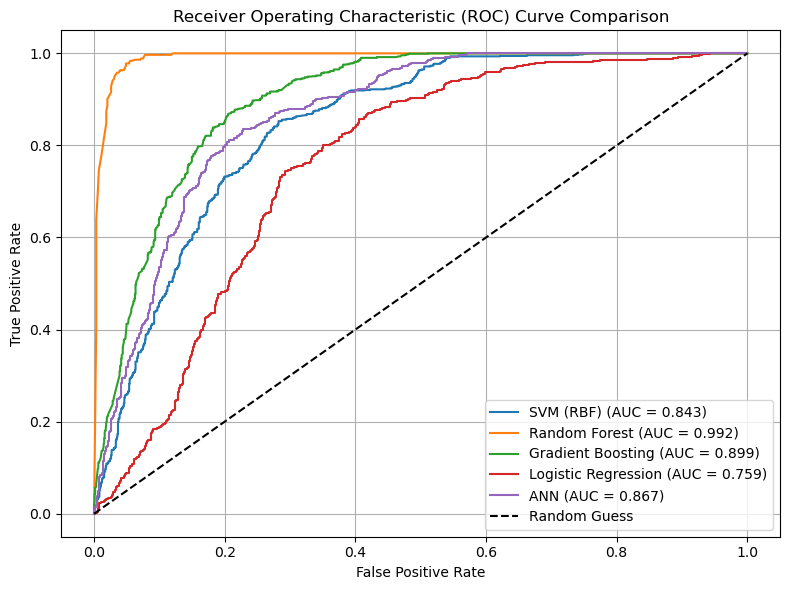

In [12]:
# =======================
# Data Preparation
# =======================
# Combine features and labels into a single dataset
data_combined = np.hstack([X_total, y_total.reshape(-1, 1)])
# Slice features (first 3 columns) and labels (last column)
X = data_combined[:, 0:3]
y = data_combined[:, -1]

# Split the dataset into training and testing sets
# Using 'stratify=y' to maintain class balance across splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
# Feature Scaling (Normalization)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# =======================
# Model Definitions
# =======================
# Dictionary of traditional Machine Learning classifiers to be evaluated
model_dict = {
    "SVM (RBF)": SVC(kernel='rbf', C=1.0, gamma='scale', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression()
}

# =======================
# Model Evaluation Function
# =======================
def evaluate_model(name, model, X_test, y_test, y_pred, y_proba):
    print(f"\n📌 [{name}]")
    print("Classification Report:")
    # Print metrics including Precision, Recall, and F1-score
    print(classification_report(y_test, y_pred, digits=4))
    
    # Calculate Area Under the ROC Curve (AUC)
    auc = roc_auc_score(y_test, y_proba)
    print(f"AUC = {auc:.4f}")
    
    # Compute and plot the ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# =======================
# Evaluate Traditional Models
# =======================
plt.figure(figsize=(8, 6))
for name, model in model_dict.items():
    model.fit(X_train_std, y_train)
    y_pred = model.predict(X_test_std)
    y_proba = model.predict_proba(X_test_std)[:, 1]
    evaluate_model(name, model, X_test_std, y_test, y_pred, y_proba)

# =======================
# Evaluate ANN (Artificial Neural Network) Model
# =======================
# Define a Sequential Deep Learning model using Keras
ann = models.Sequential([
    layers.Input(shape=(X_train_std.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary classification output
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Train the ANN (verbose=0 suppresses training logs)
ann.fit(X_train_std, y_train, epochs=30, batch_size=32, verbose=0)

# Generate predictions and probabilities for ANN
y_proba_ann = ann.predict(X_test_std).flatten()
y_pred_ann = (y_proba_ann >= 0.5).astype(int)
evaluate_model("ANN", ann, X_test_std, y_test, y_pred_ann, y_proba_ann)
# =======================
# ROC Curve Visualization
# =======================
# Plot diagonal line representing a random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step


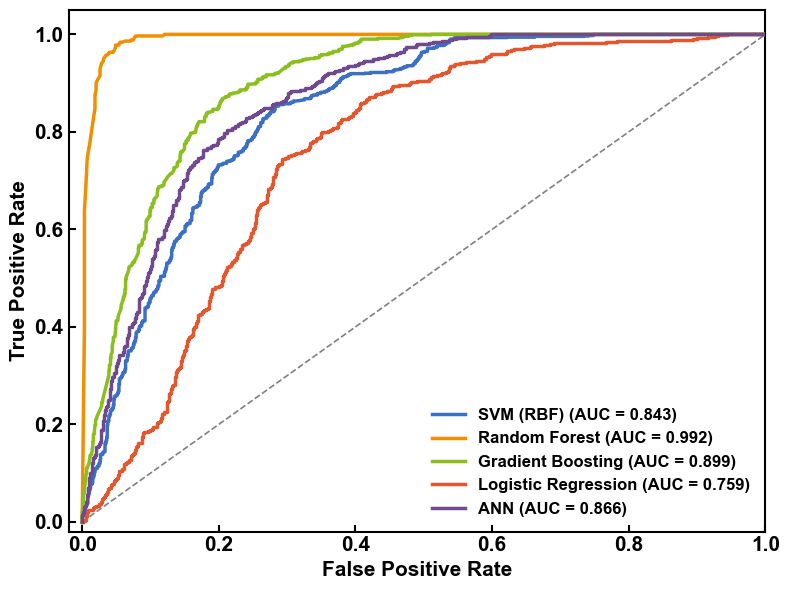

In [13]:
# Global plot configuration for high-quality scientific figures
plt.rc('font', family='Arial')
plt.rcParams.update({
    'font.weight': 'bold',
    'xtick.direction': 'in',         # Ticks point inward
    'ytick.direction': 'in',         # Ticks point inward
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
})

# =======================
# Define a distinct color palette for each model
# =======================
color_map = {
    "SVM (RBF)": "#3B70C4",
    "Random Forest": "#F18F01",
    "Gradient Boosting": "#8ABF1D",
    "Logistic Regression": "#E4572E",
    "ANN": "#6F4A8E"
}

# =======================
# Batch plotting of ROC Curves
# =======================
plt.figure(figsize=(8, 6))

# Background gradient (Optional: currently commented out)
# gradient = np.linspace(1, 0.4, 256).reshape(-1, 1)
# bg_cmap = LinearSegmentedColormap.from_list("bg", ["#F3FAFF", "#FFFFFF"])
# plt.imshow(
#      gradient,
#      aspect='auto',
#      extent=[-0.02, 1, -0.02, 1.05],
#      cmap=bg_cmap,
#      alpha=1,
#      zorder=0
# )

# Iterate through traditional Machine Learning models
for name, model in model_dict.items():
    model.fit(X_train_std, y_train)
    y_proba = model.predict_proba(X_test_std)[:, 1]

    # Calculate metrics for the ROC curve
    auc_val = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    # Plotting with specific visual styling (line width, color, and z-order)
    plt.plot(
        fpr, tpr,
        color=color_map[name],
        lw=2.5,
        label=f"{name} (AUC = {auc_val:.3f})",
        zorder=3
    )

# Artificial Neural Network (ANN) Model
ann = models.Sequential([
    layers.Input(shape=(X_train_std.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train_std, y_train, epochs=30, batch_size=32, verbose=0)

# Evaluate ANN performance
y_proba_ann = ann.predict(X_test_std).flatten()
auc_ann = roc_auc_score(y_test, y_proba_ann)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_proba_ann)

# Plot the ANN ROC curve
plt.plot(
    fpr_ann, tpr_ann,
    color=color_map["ANN"],
    lw=2.5,
    label=f"ANN (AUC = {auc_ann:.3f})",
    zorder=3
)

# Reference line for random classification (No skill)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.2, zorder=2)

# Axis limits and labels
plt.xlim([-0.02, 1.0])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate', fontsize=15, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=15, fontweight='bold')

# Legend and grid settings
plt.legend(loc='lower right', fontsize=12, frameon=False)
plt.grid(False)

# Bold the axis spines for better visibility
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()

# Save the figure as a high-resolution (300 dpi) TIFF file for publication
plt.savefig(
    "figure_Ti_Zr_rich_domain_training_result.tif",
    dpi=300,
    format='tiff',
    bbox_inches='tight'
)
plt.show()

In [ ]:

# 1. 初始化并拟合训练集
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# 2. 保存 scaler 到文件
joblib.dump(scaler, 'scaler.pkl')

# 3. 训练模型（以RF为例）
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_std, y_train)

# 4. 保存模型
joblib.dump(rf, 'rf_model.pkl')